In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Import required Libraries**

In [2]:
! pip install -q tensorflow-model-optimization

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 5.9 MB/s eta 0:00:00


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.python.core.keras.compat import keras

# **Load data**

In [4]:
batch_size = 64
img_height = 224
img_width = 224

data_dir = "/content/drive/MyDrive/New Folder/TinyML/Datasets/Tomatoes Diseases/"

In [5]:
train_ds = keras.utils.image_dataset_from_directory(
    data_dir + "Train",
    validation_split=0.2,
    subset="training",
    seed=470,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
)

Found 12860 files belonging to 10 classes.
Using 10288 files for training.


In [6]:
val_ds = keras.utils.image_dataset_from_directory(
    data_dir + "Train",
    validation_split=0.2,
    subset="validation",
    seed=470,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
)

Found 12860 files belonging to 10 classes.
Using 2572 files for validation.


In [7]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "Test",
    seed=470,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
)

Found 3198 files belonging to 10 classes.


In [8]:
class_names = train_ds.class_names
class_names

['Bacterial_spot',
 'Early_blight',
 'Late_blight',
 'Leaf_Mold',
 'Septoria_leaf_spot',
 'Spider_mite_Two_spotted_sm',
 'Target_Spot',
 'Yellow_Leaf__Curl_Virus',
 'healthy',
 'mosaic_virus']

# **Visualize the data**

In [11]:
plt.figure(figsize=(15, 15))
for img, lab in train_ds.take(1):
  for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(img[i].numpy().astype("uint8"))
    plt.title(class_names[lab[i]])
    plt.axis("off")

Output hidden; open in https://colab.research.google.com to view.

# **Preprocess the data**

In [9]:
# set 8000 images for training and 1024 images for validation
train_nds = train_ds.take(125)
val_nds = val_ds.take(16)
test_nds = test_ds.take(16)

In [10]:
# Configure the dataset for performance

AUTOTUNE = tf.data.AUTOTUNE

train_nds = train_nds.cache().prefetch(buffer_size=AUTOTUNE)
val_nds = val_nds.cache().prefetch(buffer_size=AUTOTUNE)
test_nds = test_nds.cache().prefetch(buffer_size=AUTOTUNE)

# **Load Model**

In [11]:
# Create the base model from the pre-trained model DenseNet V121

base_model = keras.applications.DenseNet121(input_shape=(img_height, img_width, 3),
                                               include_top=False,
                                               weights='imagenet')

29084464/29084464 [==============================] - 0s 0us/step


In [12]:
base_model.summary()

Model: "densenet121"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 zero_padding2d (ZeroPaddin  (None, 230, 230, 3)          0         ['input_1[0][0]']             
 g2D)                                                                                             
                                                                                                  
 conv1/conv (Conv2D)         (None, 112, 112, 64)         9408      ['zero_padding2d[0][0]']      
                                                                                                  
 conv1/bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1/conv[0][0]']

In [13]:
num_images = 8000
end_step = np.ceil(num_images / batch_size).astype(np.int32) * 30


callbacks = [tfmot.sparsity.keras.UpdatePruningStep()]

pruning_params = {
    "pruning_schedule": tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.10,
        final_sparsity=0.90,
        begin_step=0,
        end_step=end_step,)
}



In [14]:
DenseNet = tfmot.sparsity.keras.prune_low_magnitude(base_model, **pruning_params)

In [15]:
DenseNet.summary()

Model: "densenet121"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 prune_low_magnitude_zero_p  (None, 230, 230, 3)          1         ['input_1[0][0]']             
 adding2d (PruneLowMagnitud                                                                       
 e)                                                                                               
                                                                                                  
 prune_low_magnitude_conv1/  (None, 112, 112, 64)         18818     ['prune_low_magnitude_zero_pad
 conv (PruneLowMagnitude)                                           ding2d[0][0]']      

In [16]:
preprocess_input = keras.applications.densenet.preprocess_input

In [17]:
inputs = keras.Input(shape=(img_height, img_width, 3))
x = preprocess_input(inputs)
x = DenseNet(inputs, training=True)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)
outputs = tfmot.sparsity.keras.prune_low_magnitude(keras.layers.Dense(10), **pruning_params)(x)
pruned_DenseNet = keras.Model(inputs, outputs)

In [18]:
pruned_DenseNet.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 densenet121 (Functional)    (None, 7, 7, 1024)        13908258  
                                                                 
 global_average_pooling2d (  (None, 1024)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 prune_low_magnitude_dense   (None, 10)                20492     
 (PruneLowMagnitude)                                             
                                                                 
Total params: 13928750 (53.14 MB)
Trainable params: 6964106 (

# **Pruning**

# **Compile and train the model**

In [19]:
pruned_DenseNet.compile(
  loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  optimizer=keras.optimizers.Adam(learning_rate=1e-5),
  metrics=['accuracy']
)

pruned_DenseNet.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 densenet121 (Functional)    (None, 7, 7, 1024)        13908258  
                                                                 
 global_average_pooling2d (  (None, 1024)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 prune_low_magnitude_dense   (None, 10)                20492     
 (PruneLowMagnitude)                                             
                                                                 
Total params: 13928750 (53.14 MB)
Trainable params: 6964106 (

In [20]:
history = pruned_DenseNet.fit(
    train_nds,
    validation_data=val_nds,
    epochs=30,
    callbacks=callbacks,
)

Epoch 1/30
125/125 [==============================] - 1885s 13s/step - loss: 1.7502 - accuracy: 0.4087 - val_loss: 0.8989 - val_accuracy: 0.7832
Epoch 2/30
125/125 [==============================] - 101s 808ms/step - loss: 0.6946 - accuracy: 0.8056 - val_loss: 0.4824 - val_accuracy: 0.8896
Epoch 3/30
125/125 [==============================] - 102s 814ms/step - loss: 0.3878 - accuracy: 0.9082 - val_loss: 0.3245 - val_accuracy: 0.9209
Epoch 4/30
125/125 [==============================] - 102s 815ms/step - loss: 0.2603 - accuracy: 0.9414 - val_loss: 0.2584 - val_accuracy: 0.9307
Epoch 5/30
125/125 [==============================] - 107s 853ms/step - loss: 0.1969 - accuracy: 0.9609 - val_loss: 0.2192 - val_accuracy: 0.9434
Epoch 6/30
125/125 [==============================] - 101s 811ms/step - loss: 0.1677 - accuracy: 0.9653 - val_loss: 0.2011 - val_accuracy: 0.9453
Epoch 7/30
125/125 [==============================] - 102s 816ms/step - loss: 0.1537 - accuracy: 0.9701 - val_loss: 0.1808 - 

In [21]:
def plot_curves(his):

    loss = his.history['loss']
    val_loss = his.history['val_loss']

    accuracy = his.history['accuracy']
    val_accuracy = his.history['val_accuracy']

    epochs = range(len(his.history['loss']))

    # ploting the loss
    plt.plot(epochs, loss, 'r', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.figure()

    # ploting the accuracy
    plt.plot(epochs, accuracy, 'r', label='Training accuracy')
    plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.figure()

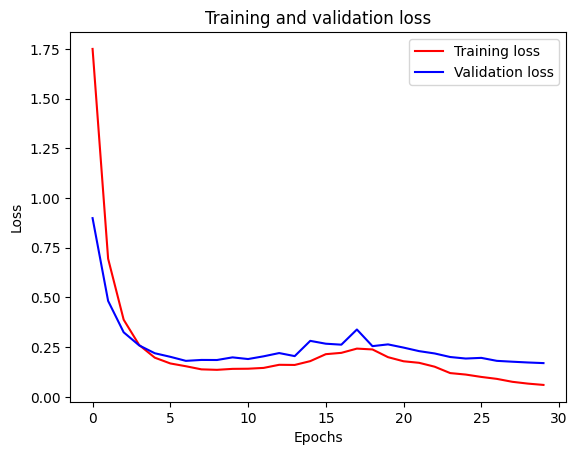

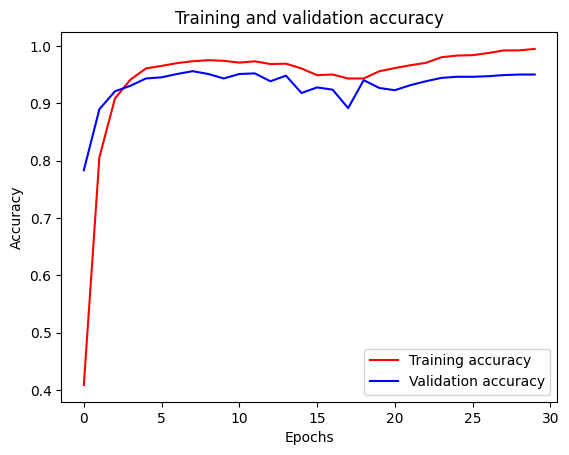

<Figure size 640x480 with 0 Axes>

In [22]:
plot_curves(history)

In [23]:
def print_model_weights_sparsity(model):
    for layer in model.layers:
        if isinstance(layer, keras.layers.Wrapper):
            weights = layer.trainable_weights
        else:
            weights = layer.weights
        for weight in weights:
            if "kernel" not in weight.name or "centroid" in weight.name:
                continue
            weight_size = weight.numpy().size
            zero_num = np.count_nonzero(weight == 0)
            print(
                f"{weight.name}: {zero_num/weight_size:.2%} sparsity ",
                f"({zero_num}/{weight_size})",
            )

In [24]:
pruned_model = tfmot.sparsity.keras.strip_pruning(pruned_DenseNet)
print_model_weights_sparsity(pruned_model)

conv1/conv/kernel:0: 90.00% sparsity  (8467/9408)
conv2_block1_1_conv/kernel:0: 90.00% sparsity  (7373/8192)
conv2_block1_2_conv/kernel:0: 90.00% sparsity  (33178/36864)
conv2_block2_1_conv/kernel:0: 90.00% sparsity  (11059/12288)
conv2_block2_2_conv/kernel:0: 90.00% sparsity  (33178/36864)
conv2_block3_1_conv/kernel:0: 90.00% sparsity  (14746/16384)
conv2_block3_2_conv/kernel:0: 90.00% sparsity  (33178/36864)
conv2_block4_1_conv/kernel:0: 90.00% sparsity  (18432/20480)
conv2_block4_2_conv/kernel:0: 90.00% sparsity  (33178/36864)
conv2_block5_1_conv/kernel:0: 90.00% sparsity  (22118/24576)
conv2_block5_2_conv/kernel:0: 90.00% sparsity  (33178/36864)
conv2_block6_1_conv/kernel:0: 90.00% sparsity  (25805/28672)
conv2_block6_2_conv/kernel:0: 90.00% sparsity  (33178/36864)
pool2_conv/kernel:0: 90.00% sparsity  (29491/32768)
conv3_block1_1_conv/kernel:0: 90.00% sparsity  (14746/16384)
conv3_block1_2_conv/kernel:0: 90.00% sparsity  (33178/36864)
conv3_block2_1_conv/kernel:0: 90.00% sparsity 

In [25]:
#pruned_model = keras.models.load_model('drive/MyDrive/New Folder/TinyML/SaveModels/pruned_DenseNet.h5')

In [26]:
pruned_model.compile(
  loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  optimizer=keras.optimizers.Adam(learning_rate=1e-5),
  metrics=['accuracy']
)

pruned_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 densenet121 (Functional)    (None, 7, 7, 1024)        7037504   
                                                                 
 global_average_pooling2d (  (None, 1024)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense (Dense)               (None, 10)                10250     
                                                                 
Total params: 7047754 (26.89 MB)
Trainable params: 6964106 (26.57 MB)
Non-trainable params: 83648 (326.75 KB)
_________________

In [27]:
loss, acc = pruned_model.evaluate(test_nds)
print("Accuracy", acc)
print("Loss", loss)

16/16 [==============================] - 282s 11s/step - loss: 0.1462 - accuracy: 0.9502
Accuracy 0.9501953125
Loss 0.14616701006889343


In [28]:
model = "drive/MyDrive/New Folder/TinyML/SaveModels/pruned_DenseNet.h5"
keras.models.save_model(pruned_model, model, include_optimizer=False)


<ipython-input-28-5064c869e294>:2: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  keras.models.save_model(pruned_model, model, include_optimizer=False)


In [29]:
# Get predictions
y_pred = pruned_model.predict(test_nds)
y_pred = np.argmax(y_pred, axis=1)

# Get true labels
y_true = np.concatenate([y for x, y in test_nds], axis=0)

# Compute confusion matrix
cm = tf.math.confusion_matrix(y_true, y_pred)

16/16 [==============================] - 6s 217ms/step


In [30]:
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[141,   0,   0,   0,   0,   0,   0,   1,   0,   0],
       [  0,  51,   7,   1,   0,   0,   4,   0,   0,   0],
       [  0,   4, 117,   4,   0,   0,   0,   0,   0,   0],
       [  0,   1,   0,  48,   1,   3,   0,   2,   0,   0],
       [  2,   1,   1,   0,  93,   0,   0,   1,   0,   0],
       [  0,   0,   0,   0,   0, 100,   5,   0,   1,   1],
       [  1,   0,   0,   0,   0,   3,  73,   0,   1,   0],
       [  2,   1,   0,   0,   0,   1,   0, 215,   0,   0],
       [  0,   0,   0,   0,   0,   0,   2,   0,  97,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  38]], dtype=int32)>

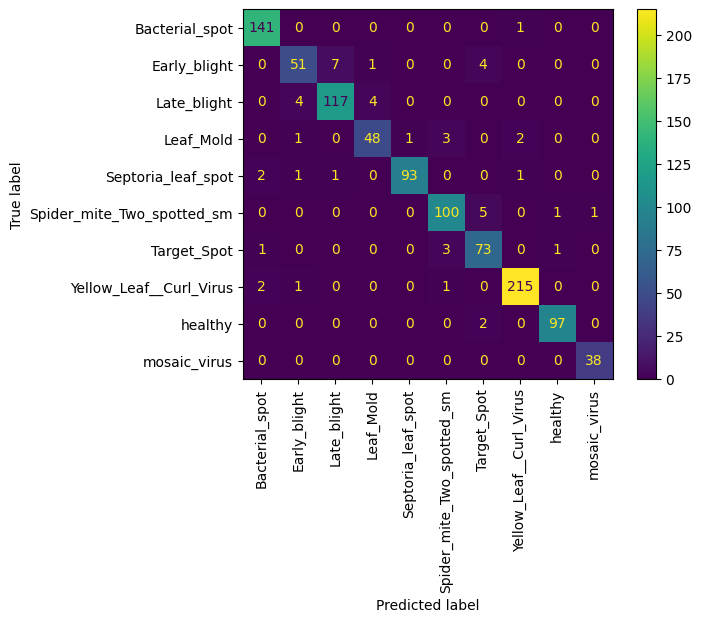

In [31]:
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, display_labels=class_names, xticks_rotation='vertical'
)

In [32]:
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print("Accuracy", acc)
print("Loss", loss)

Precision: 0.9415605021245531
Recall: 0.9392198435331794
F1 Score: 0.9400140895949015
Accuracy 0.9501953125
Loss 0.14616701006889343
